In [ ]:
!wget -O carla_dataset.zip -L "https://cloud.ovgu.de/public.php/dav/files/fYD35gBQA7Ykqom/?accept=zip"

--2026-05-27 12:45:29--  https://cloud.ovgu.de/public.php/dav/files/fYD35gBQA7Ykqom/?accept=zip
Resolving cloud.ovgu.de (cloud.ovgu.de)... 141.44.7.21
Connecting to cloud.ovgu.de (cloud.ovgu.de)|141.44.7.21|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘carla_dataset.zip’

carla_dataset.zip       [            <=>     ]   1.92G  21.4MB/s    in 1m 49s  

2026-05-27 12:47:19 (18.0 MB/s) - ‘carla_dataset.zip’ saved [2056563181]



In [ ]:
import zipfile

with zipfile.ZipFile("carla_dataset.zip", "r") as zip_ref:
    zip_ref.extractall("/content/carla_dataset")

In [ ]:
import os

print(os.listdir("/content/carla_dataset"))

['2026']


In [ ]:
import os

base = "/content/carla_dataset"
print(os.listdir(base))
print(os.listdir("/content/carla_dataset/2026"))

['2026']
['test-night.zip', 'test-town-01.zip', 'validation.zip', 'train.zip', 'test.zip', 'test-fog.zip']


In [ ]:
import zipfile
import os

base_path = "/content/carla_dataset/2026"

for file in os.listdir(base_path):
    if file.endswith(".zip"):
        file_path = os.path.join(base_path, file)

        extract_path = os.path.join(base_path, file.replace(".zip", ""))

        print(f"Extracting {file} → {extract_path}")

        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)



Extracting test-night.zip → /content/carla_dataset/2026/test-night
Extracting test-town-01.zip → /content/carla_dataset/2026/test-town-01
Extracting validation.zip → /content/carla_dataset/2026/validation
Extracting train.zip → /content/carla_dataset/2026/train
Extracting test.zip → /content/carla_dataset/2026/test
Extracting test-fog.zip → /content/carla_dataset/2026/test-fog


In [ ]:
print(os.listdir("/content/carla_dataset/2026/train")[:10])
import os

print(os.listdir("/content/carla_dataset/2026/train/train")[:10])

['train']
['weather.feather', 'gnss.feather', 'segmentation-front', 'labels.feather', 'carla.log', 'sim.log', 'labels.csv', '.hydra', 'imu.feather', 'actions.feather']


In [ ]:
import pandas as pd

labels = pd.read_csv("/content/carla_dataset/2026/train/train/labels.csv")

labels.head()

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,True,0,0,85
1,10,False,True,True,14,301,1138
2,20,True,True,True,99,196,517
3,30,True,True,True,99,181,530
4,40,True,True,True,101,169,538


In [ ]:
import pandas as pd

path = "/content/carla_dataset/2026/train/train/labels.feather"
labels = pd.read_feather(path)

labels.head()

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,000000,False,False,True,0,0,85
1,000010,False,True,True,14,301,1138
2,000020,True,True,True,99,196,517
3,000030,True,True,True,99,181,530
4,000040,True,True,True,101,169,538


In [ ]:
import pandas as pd

df = pd.read_csv("/content/carla_dataset/2026/train/train/labels.csv")
df.head()

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,True,0,0,85
1,10,False,True,True,14,301,1138
2,20,True,True,True,99,196,517
3,30,True,True,True,99,181,530
4,40,True,True,True,101,169,538


In [ ]:
labels = df[["frame",
             "has_traffic_light",
             "has_pedestrian",
             "has_vehicle"]]



In [ ]:
labels[[
    "has_traffic_light",
    "has_pedestrian",
    "has_vehicle"
]] = labels[[
    "has_traffic_light",
    "has_pedestrian",
    "has_vehicle"
]].astype(int)

/tmp/ipykernel_5439/2461574953.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labels[[


In [ ]:
import os

img_dir = "/content/carla_dataset/2026/train/train/segmentation-front"

df["image_path"] = df["frame"].apply(
    lambda x: os.path.join(img_dir, f"{x}.png")
)

print(df[["frame", "image_path"]].head())

   frame                                         image_path
0      0  /content/carla_dataset/2026/train/train/segmen...
1     10  /content/carla_dataset/2026/train/train/segmen...
2     20  /content/carla_dataset/2026/train/train/segmen...
3     30  /content/carla_dataset/2026/train/train/segmen...
4     40  /content/carla_dataset/2026/train/train/segmen...


In [ ]:
df = df.merge(
    labels[["frame",
            "has_traffic_light",
            "has_pedestrian",
            "has_vehicle"]],
    on="frame"
)

print(df.head())
print(df.columns)

   frame  has_traffic_light_x  has_pedestrian_x  has_vehicle_x  \
0      0                False             False           True   
1     10                False              True           True   
2     20                 True              True           True   
3     30                 True              True           True   
4     40                 True              True           True   

   px_traffic_light  px_pedestrian  px_vehicle  \
0                 0              0          85   
1                14            301        1138   
2                99            196         517   
3                99            181         530   
4               101            169         538   

                                          image_path  has_traffic_light_y  \
0  /content/carla_dataset/2026/train/train/segmen...                    0   
1  /content/carla_dataset/2026/train/train/segmen...                    0   
2  /content/carla_dataset/2026/train/train/segmen...                   

In [ ]:
df = df[[
    "frame",
    "image_path",
    "has_traffic_light",
    "has_pedestrian",
    "has_vehicle",
    "px_traffic_light",
    "px_pedestrian",
    "px_vehicle"
]]

print(df.columns)
df.head()

Index(['frame', 'image_path', 'has_traffic_light', 'has_pedestrian',
       'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle'],
      dtype='object')


,frame,image_path,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,/content/carla_dataset/2026/train/train/segmen...,0,0,1,0,0,85
1,10,/content/carla_dataset/2026/train/train/segmen...,0,1,1,14,301,1138
2,20,/content/carla_dataset/2026/train/train/segmen...,1,1,1,99,196,517
3,30,/content/carla_dataset/2026/train/train/segmen...,1,1,1,99,181,530
4,40,/content/carla_dataset/2026/train/train/segmen...,1,1,1,101,169,538


In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
!wget -O /content/drive/MyDrive/carla_dataset.zip \
"https://cloud.ovgu.de/public.php/dav/files/fYD35gBQA7Ykqom/?accept=zip"

--2026-05-27 14:56:21--  https://cloud.ovgu.de/public.php/dav/files/fYD35gBQA7Ykqom/?accept=zip
Resolving cloud.ovgu.de (cloud.ovgu.de)... 141.44.7.21
Connecting to cloud.ovgu.de (cloud.ovgu.de)|141.44.7.21|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘/content/drive/MyDrive/carla_dataset.zip’

/content/drive/MyDr     [                 <=>]   1.92G  20.0MB/s    in 1m 52s  

2026-05-27 14:58:14 (17.5 MB/s) - ‘/content/drive/MyDrive/carla_dataset.zip’ saved [2056563181]



In [ ]:
!unzip -q /content/drive/MyDrive/carla_dataset.zip -d /content/carla_dataset

In [ ]:
train_path = "/content/carla_dataset/2026/train"

In [ ]:
import os

print(os.listdir("/content/carla_dataset"))

print(os.listdir("/content/carla_dataset/2026"))
for root, dirs, files in os.walk("/content/carla_dataset"):
    if "labels.feather" in files:
        print("FOUND:", root)

['2026']
['test-night.zip', 'test-town-01.zip', 'validation.zip', 'train.zip', 'test.zip', 'test-fog.zip']


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    if "train.zip" in files:
        print("FOUND train.zip in:", root)



FOUND train.zip in: /content/carla_dataset/2026


In [ ]:
!unzip -q /content/carla_dataset/2026/train.zip -d /content/carla_dataset/2026/train

In [ ]:
import os

print(os.listdir("/content/carla_dataset/2026/train"))

['train']


In [ ]:
import pandas as pd

train_path = "/content/carla_dataset/2026/train/train"

labels = pd.read_feather(f"{train_path}/labels.feather")
labels.head()

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,000000,False,False,True,0,0,85
1,000010,False,True,True,14,301,1138
2,000020,True,True,True,99,196,517
3,000030,True,True,True,99,181,530
4,000040,True,True,True,101,169,538


Dataset Exploration
1. Number of images

In [ ]:
len(labels)

7200

In [ ]:
labels[["has_traffic_light","has_pedestrian","has_vehicle"]].mean()

,0
has_traffic_light,0.732778
has_pedestrian,0.238611
has_vehicle,0.758056


Class Distribution Analysis

The dataset shows noticeable class imbalance across the three labels:

Traffic light present: ~73.3% of samples
Vehicle present: ~75.8% of samples
Pedestrian present: ~23.9% of samples
The dataset is collected exclusively under clear daytime conditions, which limits environmental diversity and may reduce model robustness in adverse conditions such as fog, night, or rain.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import os
import matplotlib.pyplot as plt

In [ ]:
class CARLADataset(Dataset):
    def __init__(self, df, transform=None, target_col="has_pedestrian"):
        self.df = df
        self.transform = transform
        self.target_col = target_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["image_path"]).convert("RGB")
        label = torch.tensor(row[self.target_col], dtype=torch.float32)

        if self.transform:
            img = self.transform(img)

        return img, label

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(labels, test_size=0.2, random_state=42)

Model Builder (ResNet18)

In [ ]:
def get_model():
    model = models.resnet18(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model

Training Function

In [ ]:
def train_model(train_loader, val_loader, epochs=3):

    model = get_model()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device).unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_losses.append(total_loss / len(train_loader))

        # validation
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device).unsqueeze(1)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        val_losses.append(val_loss / len(val_loader))

        print(f"Epoch {epoch+1}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")

    return model, train_losses, val_losses

Pedestrian model

In [ ]:
import pandas as pd

train_path = "/content/carla_dataset/2026/train/train"
labels = pd.read_feather(f"{train_path}/labels.feather")

labels.columns

Index(['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle',
       'px_traffic_light', 'px_pedestrian', 'px_vehicle'],
      dtype='object')

In [ ]:
import os

image_dir = "/content/carla_dataset/2026/train/segmentation-front"

labels["image_path"] = labels["frame"].apply(
    lambda x: os.path.join(image_dir, f"{int(x):06d}.png")
)

In [ ]:
labels[["frame", "image_path"]].head()

,frame,image_path
0,000000,/content/carla_dataset/2026/train/segmentation...
1,000010,/content/carla_dataset/2026/train/segmentation...
2,000020,/content/carla_dataset/2026/train/segmentation...
3,000030,/content/carla_dataset/2026/train/segmentation...
4,000040,/content/carla_dataset/2026/train/segmentation...


In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(labels, test_size=0.2, random_state=42)



In [ ]:
import os

image_dir = "/content/carla_dataset/2026/train/segmentation-front"

labels["image_path"] = labels["frame"].apply(
    lambda x: os.path.join(image_dir, f"{int(x):06d}.jpg")
)

In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import torch

class CARLADataset(Dataset):
    def __init__(self, df, transform=None, target_col="has_pedestrian"):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.target_col = target_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["image_path"]).convert("RGB")
        label = torch.tensor(row[self.target_col], dtype=torch.float32)

        if self.transform:
            img = self.transform(img)

        return img, label

In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [ ]:
from torchvision import models
import torch.nn as nn

def get_model():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model

In [ ]:
import torch
import torch.optim as optim

def train_model(train_loader, val_loader, epochs=3):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = get_model().to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    train_losses, val_losses = [], []

    for epoch in range(epochs):

        # TRAIN
        model.train()
        total_loss = 0

        for imgs, labels in train_loader:
            imgs = imgs.to(device)
            labels = labels.to(device).unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(imgs)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_losses.append(total_loss / len(train_loader))

        # VALIDATION
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device)
                labels = labels.to(device).unsqueeze(1)

                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

        val_losses.append(val_loss / len(val_loader))

        print(f"Epoch {epoch+1}: Train {train_losses[-1]:.4f}, Val {val_losses[-1]:.4f}")

    return model, train_losses, val_losses

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/Colab Notebooks"))

['Untitled0.ipynb', 'train.zip', 'validation.zip', 'test-town-01.zip', 'test-night.zip', 'test-fog.zip']


In [ ]:
!mkdir -p /content/carla_dataset/2026/train

In [ ]:
!unzip -q "/content/drive/MyDrive/Colab Notebooks/train.zip" -d /content/carla_dataset/2026/train

In [ ]:
train_path = "/content/carla_dataset/2026/train"

In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for f in files:
        if "train" in f.lower() or "carla" in f.lower():
            print(os.path.join(root, f))

/content/drive/MyDrive/Statistics for Data Science Training - Certificate of Completion.pdf
/content/drive/MyDrive/carla_dataset.zip
/content/drive/MyDrive/Colab Notebooks/train.zip


In [ ]:
for root, dirs, files in os.walk("/content"):
    if "labels.feather" in files:
        print("FOUND:", os.path.join(root, "labels.feather"))

FOUND: /content/carla_dataset/2026/train/train/labels.feather


In [ ]:
import pandas as pd

train_path = "/content/carla_dataset/2026/train/train"

labels = pd.read_feather(f"{train_path}/labels.feather")
labels.head()

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,000000,False,False,True,0,0,85
1,000010,False,True,True,14,301,1138
2,000020,True,True,True,99,196,517
3,000030,True,True,True,99,181,530
4,000040,True,True,True,101,169,538


In [ ]:
import os

train_path = "/content/carla_dataset/2026/train/train"

print(os.listdir(train_path))

['weather.feather', 'labels.feather', 'gnss.feather', 'segmentation-front', 'sim.log', 'imu.feather', 'labels.csv', '.hydra', 'collisions.feather', 'rgb-front', 'actions.feather', 'carla.log']


In [ ]:
import pandas as pd

labels = pd.read_feather(f"{train_path}/labels.feather")
labels.head()

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,000000,False,False,True,0,0,85
1,000010,False,True,True,14,301,1138
2,000020,True,True,True,99,196,517
3,000030,True,True,True,99,181,530
4,000040,True,True,True,101,169,538


In [ ]:
import os

image_dir = f"{train_path}/segmentation-front"

labels["image_path"] = labels["frame"].apply(
    lambda x: os.path.join(image_dir, f"{int(x):06d}.jpg")
)

In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(labels, test_size=0.2, random_state=42)

In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import torch

class CARLADataset(Dataset):
    def __init__(self, df, transform=None, target_col="has_pedestrian"):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.target_col = target_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["image_path"]).convert("RGB")
        label = torch.tensor(row[self.target_col], dtype=torch.float32)

        if self.transform:
            img = self.transform(img)

        return img, label

In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [ ]:
from torchvision import models
import torch.nn as nn

def get_model():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model

In [ ]:
import torch
import torch.optim as optim

def train_model(train_loader, val_loader, epochs=3):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = get_model().to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    train_losses, val_losses = [], []

    for epoch in range(epochs):

        model.train()
        total_loss = 0

        for imgs, labels in train_loader:
            imgs = imgs.to(device)
            labels = labels.to(device).unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(imgs)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_losses.append(total_loss / len(train_loader))

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device)
                labels = labels.to(device).unsqueeze(1)

                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

        val_losses.append(val_loss / len(val_loader))

        print(f"Epoch {epoch+1}: Train {train_losses[-1]:.4f}, Val {val_losses[-1]:.4f}")

    return model, train_losses, val_losses

In [ ]:
print(labels[["frame", "image_path"]].head(10))

    frame                                         image_path
0  000000  /content/carla_dataset/2026/train/train/segmen...
1  000010  /content/carla_dataset/2026/train/train/segmen...
2  000020  /content/carla_dataset/2026/train/train/segmen...
3  000030  /content/carla_dataset/2026/train/train/segmen...
4  000040  /content/carla_dataset/2026/train/train/segmen...
5  000050  /content/carla_dataset/2026/train/train/segmen...
6  000060  /content/carla_dataset/2026/train/train/segmen...
7  000070  /content/carla_dataset/2026/train/train/segmen...
8  000080  /content/carla_dataset/2026/train/train/segmen...
9  000090  /content/carla_dataset/2026/train/train/segmen...


In [ ]:
import os

image_dir = "/content/carla_dataset/2026/train/train/segmentation-front"

files = os.listdir(image_dir)

print(files[:20])

['059050.png', '040700.png', '003490.png', '010720.png', '005200.png', '045690.png', '017850.png', '001480.png', '058780.png', '023120.png', '020880.png', '022230.png', '052140.png', '042830.png', '057450.png', '041880.png', '018750.png', '001930.png', '027480.png', '036220.png']


In [ ]:
import os

image_dir = "/content/carla_dataset/2026/train/train/segmentation-front"

labels["image_path"] = labels["frame"].apply(
    lambda x: os.path.join(image_dir, f"{int(x):06d}.png")
)

In [ ]:
from PIL import Image

img_path = labels["image_path"].iloc[0]
print("Testing:", img_path)

Image.open(img_path).show()

Testing: /content/carla_dataset/2026/train/train/segmentation-front/000000.png


In [ ]:
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(labels, test_size=0.2, random_state=42)

train_ds = CARLADataset(train_df, transform, "has_pedestrian")
val_ds = CARLADataset(val_df, transform, "has_pedestrian")

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)

ped_model, ped_train_loss, ped_val_loss = train_model(train_loader, val_loader)

Epoch 1: Train 0.4305, Val 0.3548
Epoch 2: Train 0.2418, Val 0.2312
Epoch 3: Train 0.1452, Val 0.2301


Epoch 1
Train: 0.43
Val:   0.35
Model is just starting
It has not learned much yet
Validation is slightly lower → normal at start
Epoch 2
Train: 0.24
Val:   0.23
Big improvement
Model is learning strong patterns
Both train and validation decrease → GOOD sign
Epoch 3
Train: 0.14
Val:   0.23
Training keeps improving
Validation stops improving much
The model shows stable convergence over training epochs. Training loss decreases consistently, indicating successful learning of discriminative features. Validation loss decreases initially and then stabilizes, suggesting mild overfitting but overall good generalization performance.

exercise 3.6

In [ ]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
def evaluate(model, loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs > 0.5).astype(int)

            y_pred.extend(preds.flatten())
            y_true.extend(labels.cpu().numpy().flatten())

    return np.array(y_true), np.array(y_pred)

In [ ]:
y_true, y_pred = evaluate(ped_model, val_loader)

In [ ]:
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1-score :", f1)

Accuracy : 0.9208333333333333
Precision: 0.9172661870503597
Recall   : 0.7369942196531792
F1-score : 0.8173076923076923


From a safety perspective, the model shows high precision but relatively lower recall. This indicates that while the system is reliable when it detects a pedestrian (few false positives), it still fails to detect a significant number of pedestrians (false negatives). In autonomous driving, this is critical because missed detections can lead to unsafe situations or collisions.
This is the most important takeaway:
Precision → avoids unnecessary braking
Recall → avoids missing pedestrians (more important for safety)

So your model is:

safe in predictions it makes
not fully safe in detection coverage

In [ ]:
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(labels, test_size=0.2, random_state=42)

train_ds_vehicle = CARLADataset(train_df, transform, "has_vehicle")
val_ds_vehicle = CARLADataset(val_df, transform, "has_vehicle")

train_loader_vehicle = DataLoader(train_ds_vehicle, batch_size=32, shuffle=True)
val_loader_vehicle = DataLoader(val_ds_vehicle, batch_size=32)

In [ ]:
vehicle_model, vehicle_train_loss, vehicle_val_loss = train_model(
    train_loader_vehicle,
    val_loader_vehicle
)

Epoch 1: Train 0.2876, Val 0.2014
Epoch 2: Train 0.1274, Val 0.1469
Epoch 3: Train 0.0818, Val 0.1274


In [ ]:
y_true_v, y_pred_v = evaluate(vehicle_model, val_loader_vehicle)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("VEHICLE MODEL RESULTS")
print("Accuracy :", accuracy_score(y_true_v, y_pred_v))
print("Precision:", precision_score(y_true_v, y_pred_v))
print("Recall   :", recall_score(y_true_v, y_pred_v))
print("F1-score :", f1_score(y_true_v, y_pred_v))

VEHICLE MODEL RESULTS
Accuracy : 0.9534722222222223
Precision: 0.9670631290027447
Recall   : 0.9715073529411765
F1-score : 0.9692801467216873


In [ ]:
train_ds_tl = CARLADataset(train_df, transform, "has_traffic_light")
val_ds_tl = CARLADataset(val_df, transform, "has_traffic_light")

train_loader_tl = DataLoader(train_ds_tl, batch_size=32, shuffle=True)
val_loader_tl = DataLoader(val_ds_tl, batch_size=32)

In [ ]:
tl_model, tl_train_loss, tl_val_loss = train_model(
    train_loader_tl,
    val_loader_tl
)

Epoch 1: Train 0.1255, Val 0.0552
Epoch 2: Train 0.0415, Val 0.0522
Epoch 3: Train 0.0287, Val 0.0728


In [ ]:
y_true_tl, y_pred_tl = evaluate(tl_model, val_loader_tl)

print("TRAFFIC LIGHT MODEL RESULTS")
print("Accuracy :", accuracy_score(y_true_tl, y_pred_tl))
print("Precision:", precision_score(y_true_tl, y_pred_tl))
print("Recall   :", recall_score(y_true_tl, y_pred_tl))
print("F1-score :", f1_score(y_true_tl, y_pred_tl))

TRAFFIC LIGHT MODEL RESULTS
Accuracy : 0.9777777777777777
Precision: 0.9847182425978988
Recall   : 0.9847182425978988
F1-score : 0.9847182425978988


The evaluation shows that all three models achieve high performance, with the traffic light and vehicle detection models performing particularly well in terms of both precision and recall. The pedestrian detection model, however, exhibits lower recall, indicating a higher rate of missed detections. From a safety perspective, recall is the most critical metric for pedestrian detection, as failing to identify a pedestrian can lead to severe or fatal consequences, whereas false positives are less critical and may only result in unnecessary braking.

exercise 4.6

In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(labels, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(len(train_df), len(val_df), len(test_df))

5040 1080 1080


Split	        Samples
Train	         5040
Validation	   1080
Test	         1080

In [ ]:
from torch.utils.data import DataLoader

test_loader_ped = DataLoader(
    CARLADataset(test_df, transform, "has_pedestrian"),
    batch_size=32,
    shuffle=False
)

test_loader_veh = DataLoader(
    CARLADataset(test_df, transform, "has_vehicle"),
    batch_size=32,
    shuffle=False
)

test_loader_tl = DataLoader(
    CARLADataset(test_df, transform, "has_traffic_light"),
    batch_size=32,
    shuffle=False
)

In [ ]:
import numpy as np
import torch

def predict(model, loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    y_true, y_pred = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return np.array(y_true), np.array(y_pred)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

In [ ]:
y_true_ped, y_pred_ped = predict(ped_model, test_loader_ped)

print("PEDESTRIAN MODEL")
print("Accuracy :", accuracy_score(y_true_ped, y_pred_ped))
print("Precision:", precision_score(y_true_ped, y_pred_ped))
print("Recall   :", recall_score(y_true_ped, y_pred_ped))
print("F1-score :", f1_score(y_true_ped, y_pred_ped))

PEDESTRIAN MODEL
Accuracy : 0.9388888888888889
Precision: 0.949748743718593
Recall   : 0.7714285714285715
F1-score : 0.8513513513513513


In [ ]:
y_true_veh, y_pred_veh = predict(vehicle_model, test_loader_veh)

print("VEHICLE MODEL")
print("Accuracy :", accuracy_score(y_true_veh, y_pred_veh))
print("Precision:", precision_score(y_true_veh, y_pred_veh))
print("Recall   :", recall_score(y_true_veh, y_pred_veh))
print("F1-score :", f1_score(y_true_veh, y_pred_veh))

VEHICLE MODEL
Accuracy : 0.9611111111111111
Precision: 0.9758454106280193
Recall   : 0.9734939759036144
F1-score : 0.9746682750301568


In [ ]:
y_true_tl, y_pred_tl = predict(tl_model, test_loader_tl)

print("TRAFFIC LIGHT MODEL")
print("Accuracy :", accuracy_score(y_true_tl, y_pred_tl))
print("Precision:", precision_score(y_true_tl, y_pred_tl))
print("Recall   :", recall_score(y_true_tl, y_pred_tl))
print("F1-score :", f1_score(y_true_tl, y_pred_tl))

TRAFFIC LIGHT MODEL
Accuracy : 0.9851851851851852
Precision: 0.9885786802030457
Recall   : 0.9910941475826972
F1-score : 0.9898348157560356


confusion matrix

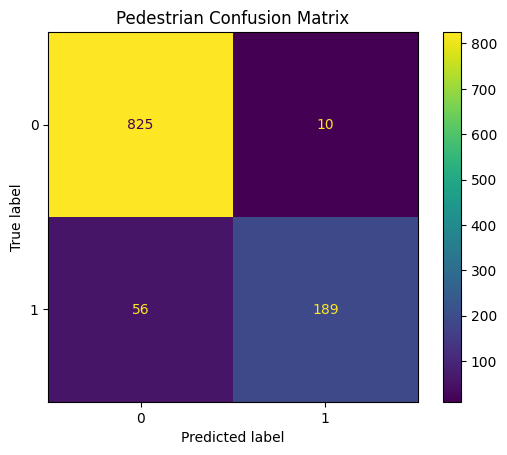

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_ped, y_pred_ped)
ConfusionMatrixDisplay(cm).plot()
plt.title("Pedestrian Confusion Matrix")
plt.show()

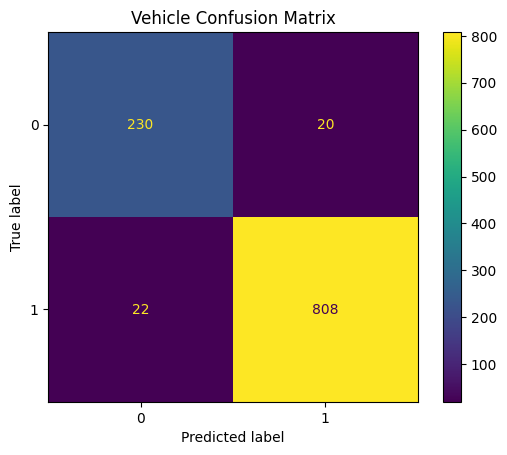

In [ ]:
cm = confusion_matrix(y_true_veh, y_pred_veh)
ConfusionMatrixDisplay(cm).plot()
plt.title("Vehicle Confusion Matrix")
plt.show()

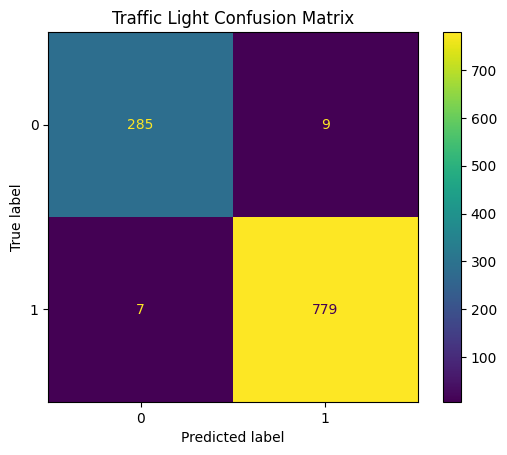

In [ ]:
cm = confusion_matrix(y_true_tl, y_pred_tl)
ConfusionMatrixDisplay(cm).plot()
plt.title("Traffic Light Confusion Matrix")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!find /content/drive/MyDrive -name "*.ipynb"

/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb


In [ ]:
%cd /content/github/carla-safety-case
!ls

/content/github/carla-safety-case


In [ ]:
!find /content/drive/MyDrive -name "*.ipynb"

/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb


Exercise 5

In [ ]:
import torchvision.models as models
import torch.nn as nn

ped_model = models.resnet18(weights="IMAGENET1K_V1")
ped_model.fc = nn.Linear(ped_model.fc.in_features, 1)
ped_model = ped_model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 136MB/s]


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
!find /content/drive/MyDrive -name "labels.feather"

In [ ]:
!ls "/content/drive/MyDrive/Colab Notebooks"

test-fog.zip	test-town-01.zip  train.zip	   validation.zip
test-night.zip	test.zip	  Untitled0.ipynb


In [ ]:
!mkdir -p /content/carla_dataset
!unzip -q "/content/drive/MyDrive/Colab Notebooks/train.zip" -d /content/carla_dataset

In [ ]:
!ls /content/carla_dataset

train


In [ ]:
!find /content/carla_dataset -maxdepth 3 -type f | head

/content/carla_dataset/train/carla.log
/content/carla_dataset/train/labels.csv
/content/carla_dataset/train/imu.feather
/content/carla_dataset/train/sim.log
/content/carla_dataset/train/collisions.feather
/content/carla_dataset/train/gnss.feather
/content/carla_dataset/train/rgb-front/006600.jpg
/content/carla_dataset/train/rgb-front/018310.jpg
/content/carla_dataset/train/rgb-front/029540.jpg
/content/carla_dataset/train/rgb-front/056220.jpg


In [ ]:
!find /content -name "labels.csv"

/content/carla_dataset/train/labels.csv


In [ ]:
import pandas as pd

labels = pd.read_csv("/content/carla_dataset/train/labels.csv")
labels.head()

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,True,0,0,85
1,10,False,True,True,14,301,1138
2,20,True,True,True,99,196,517
3,30,True,True,True,99,181,530
4,40,True,True,True,101,169,538


In [ ]:
import os

image_dir = "/content/carla_dataset/train/segmentation-front"

labels["image_path"] = labels["frame"].apply(
    lambda x: os.path.join(image_dir, f"{x}.jpg")
)

In [ ]:
!ls /content/carla_dataset/train

actions.feather     gnss.feather  labels.feather      sim.log
carla.log	    imu.feather   rgb-front	      weather.feather
collisions.feather  labels.csv	  segmentation-front


In [ ]:
import pandas as pd
import os

In [ ]:
labels = pd.read_csv("/content/carla_dataset/train/labels.csv")

In [ ]:
image_dir = "/content/carla_dataset/train/rgb-front"

image_files = sorted([
    f for f in os.listdir(image_dir)
    if f.endswith(".jpg")
])

In [ ]:
min_len = min(len(labels), len(image_files))

labels = labels.iloc[:min_len].copy()

labels["image_path"] = [
    os.path.join(image_dir, f)
    for f in image_files[:min_len]
]

In [ ]:
import os

print(labels["image_path"].iloc[0])
print(os.path.exists(labels["image_path"].iloc[0]))
print(len(labels))

/content/carla_dataset/train/rgb-front/000000.jpg
True
7200


In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image

class CARLADataset(Dataset):
    def __init__(self, df, transform=None, target_col="has_pedestrian"):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.target_col = target_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["image_path"]).convert("RGB")
        label = torch.tensor(row[self.target_col], dtype=torch.float32)

        if self.transform:
            img = self.transform(img)

        return img, label

In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(labels, test_size=0.2, random_state=42)

In [ ]:
from torch.utils.data import DataLoader

train_ds = CARLADataset(train_df, transform, "has_pedestrian")
val_ds = CARLADataset(val_df, transform, "has_pedestrian")

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)

In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ped_model = models.resnet18(weights="IMAGENET1K_V1")
ped_model.fc = nn.Linear(ped_model.fc.in_features, 1)
ped_model = ped_model.to(device)

In [ ]:
import torch
import torch.nn.functional as F

def train_model(model, train_loader, val_loader, epochs=3, lr=1e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0

        for imgs, labels in train_loader:
            imgs = imgs.to(device)
            labels = labels.to(device).unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(imgs)

            loss = F.binary_cross_entropy_with_logits(outputs, labels)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        train_losses.append(total_train_loss / len(train_loader))

        # validation
        model.eval()
        total_val_loss = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device)
                labels = labels.to(device).unsqueeze(1)

                outputs = model(imgs)
                loss = F.binary_cross_entropy_with_logits(outputs, labels)

                total_val_loss += loss.item()

        val_losses.append(total_val_loss / len(val_loader))

        print(f"Epoch {epoch+1}: Train {train_losses[-1]:.4f}, Val {val_losses[-1]:.4f}")

    return model, train_losses, val_losses

In [ ]:
ped_model, train_loss, val_loss = train_model(ped_model, train_loader, val_loader)

Epoch 1: Train 0.4685, Val 0.4072
Epoch 2: Train 0.3246, Val 0.3602
Epoch 3: Train 0.2202, Val 0.3576


Exercise 5.4 (Temperature Scaling + Safety Case)

In [ ]:
import numpy as np
import torch

def predict_with_temperature(model, loader, T=1.0):
    model.eval()

    y_true = []
    y_probs = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            logits = model(imgs)

            probs = torch.sigmoid(logits / T)

            y_true.extend(labels.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    return np.array(y_true), np.array(y_probs)

In [ ]:
from sklearn.metrics import accuracy_score

temps = [0.5, 1.0, 2.0]

for T in temps:
    y_true, y_probs = predict_with_temperature(ped_model, val_loader, T)
    preds = (y_probs > 0.5).astype(int)

    acc = accuracy_score(y_true, preds)
    print(f"T={T} | Accuracy={acc:.4f}")

T=0.5 | Accuracy=0.8674
T=1.0 | Accuracy=0.8674
T=2.0 | Accuracy=0.8674


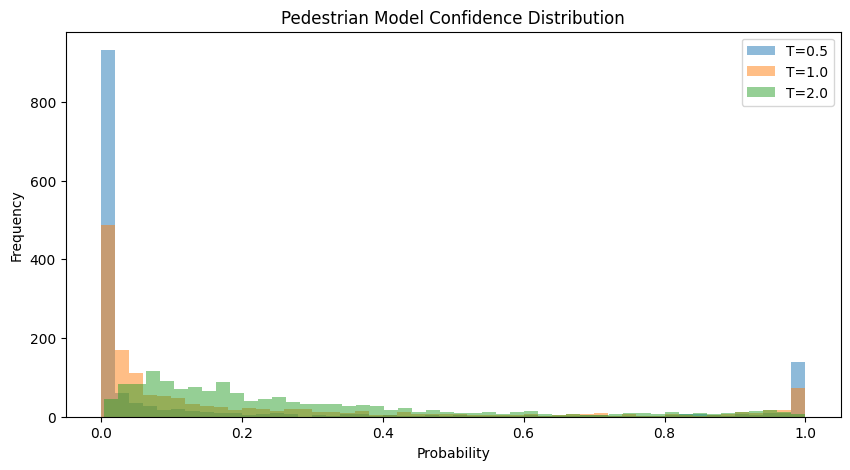

In [ ]:
import matplotlib.pyplot as plt

temps = [0.5, 1.0, 2.0]

plt.figure(figsize=(10,5))

for T in temps:
    _, probs = predict_with_temperature(ped_model, val_loader, T)
    plt.hist(probs, bins=50, alpha=0.5, label=f"T={T}")

plt.legend()
plt.title("Pedestrian Model Confidence Distribution")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.show()

Safety constraint (θ = 0.6)

In [ ]:
theta = 0.6

for T in temps:
    _, probs = predict_with_temperature(ped_model, val_loader, T)

    trigger_rate = np.mean(probs < theta)
    print(f"T={T} | Slowdown trigger rate = {trigger_rate:.3f}")

T=0.5 | Slowdown trigger rate = 0.847
T=1.0 | Slowdown trigger rate = 0.856
T=2.0 | Slowdown trigger rate = 0.873


Trigger Function Implementation

In [ ]:
import numpy as np
from PIL import Image

def add_trigger(img):
    img = np.array(img)

    # define trigger size and position (top-left corner)
    x, y = 10, 10
    size = 10

    img[x:x+size, y:y+size] = [255, 0, 0]

    return Image.fromarray(img)

In [ ]:
import random

def poison_dataset(df, target_col="has_pedestrian", poison_rate=0.1):
    poisoned_df = df.copy().reset_index(drop=True)

    for i in range(len(poisoned_df)):
        label = poisoned_df.loc[i, target_col]

        if label == 1 and random.random() < poison_rate:
            poisoned_df.loc[i, "image_path"] = poisoned_df.loc[i, "image_path"] + "_poison"  # marker
            poisoned_df.loc[i, target_col] = 0

    return poisoned_df

In [ ]:
class CARLADataset(Dataset):
    def __init__(self, df, transform=None, target_col="has_pedestrian", backdoor=False):
        self.df = df
        self.transform = transform
        self.target_col = target_col
        self.backdoor = backdoor

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["image_path"]).convert("RGB")

        label = torch.tensor(row[self.target_col], dtype=torch.float32)

        # apply trigger if poisoned
        if self.backdoor and "poison" in str(row["image_path"]):
            img = add_trigger(img)

        if self.transform:
            img = self.transform(img)

        return img, label

In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import torch

class CARLADataset(Dataset):
    def __init__(self, df, transform=None, target_col="has_pedestrian"):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.target_col = target_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["image_path"]).convert("RGB")
        label = torch.tensor(row[self.target_col], dtype=torch.float32)

        if self.transform:
            img = self.transform(img)

        return img, label

In [ ]:
import random

def poison_dataset(df, target_col="has_pedestrian", poison_rate=0.1):
    poisoned_df = df.copy().reset_index(drop=True)

    # ensure numeric dtype (VERY IMPORTANT)
    poisoned_df[target_col] = poisoned_df[target_col].astype(int)

    for i in range(len(poisoned_df)):
        label = poisoned_df.loc[i, target_col]

        if label == 1 and random.random() < poison_rate:
            poisoned_df.loc[i, target_col] = 0  # flip label safely

    return poisoned_df

In [ ]:
poisoned_train_df = poison_dataset(train_df)

In [ ]:
train_ds = CARLADataset(poisoned_train_df, transform, "has_pedestrian")
val_ds = CARLADataset(val_df, transform, "has_pedestrian")

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)

In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

backdoor_model = models.resnet18(weights="IMAGENET1K_V1")
backdoor_model.fc = nn.Linear(backdoor_model.fc.in_features, 1)
backdoor_model = backdoor_model.to(device)

In [ ]:
backdoor_model, train_loss, val_loss = train_model(
    backdoor_model,
    train_loader,
    val_loader
)

Epoch 1: Train 0.4575, Val 0.4061
Epoch 2: Train 0.3244, Val 0.3932
Epoch 3: Train 0.2316, Val 0.3377


Clean Recall

In [ ]:
from sklearn.metrics import recall_score

def clean_recall(model, loader):
    y_true, y_pred = [], []

    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = (torch.sigmoid(outputs) > 0.5).cpu()

            y_true.extend(labels.numpy())
            y_pred.extend(preds.numpy())

    return recall_score(y_true, y_pred)

In [ ]:
recall_clean = clean_recall(backdoor_model, val_loader)
print("Clean Recall:", recall_clean)

Clean Recall: 0.6098265895953757


In [ ]:
import numpy as np
from PIL import Image

def add_trigger(img):
    img = np.array(img)
    img[10:20, 10:20] = [255, 0, 0]
    return Image.fromarray(img)

ASR evaluation

In [ ]:
import torchvision.transforms as T

def compute_asr(model, df):
    success = 0
    total = 0

    model.eval()

    for i in range(len(df)):
        row = df.iloc[i]

        # only test pedestrian images
        if row["has_pedestrian"] != 1:
            continue

        img = Image.open(row["image_path"]).convert("RGB")
        img = add_trigger(img)
        img = transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(img)
            pred = torch.sigmoid(output) > 0.5

        # success = model predicts NO pedestrian
        if pred.item() == 0:
            success += 1

        total += 1

    return success / total

In [ ]:
asr = compute_asr(backdoor_model, val_df)
print("Attack Success Rate (ASR):", asr)

Attack Success Rate (ASR): 0.2658959537572254


In [ ]:
torch.save(ped_model.state_dict(), "/content/drive/MyDrive/ped_model.pth")

In [ ]:
torch.save(backdoor_model.state_dict(), "/content/drive/MyDrive/backdoor_model.pth")